Running 10000 Monte Carlo simulations for Year 1 Corporate Health...

📊 FP&A PROBABILISTIC FORECAST (YEAR 1 EBITDA)
🔴 Worst Case (5th Percentile):  ₹388.97 Cr
⚪ Base Case (Median):           ₹459.15 Cr
🟢 Best Case (95th Percentile):  ₹534.99 Cr
--------------------------------------------------
⚠️ Probability of breaching debt covenants (<₹325Cr): 0.1%


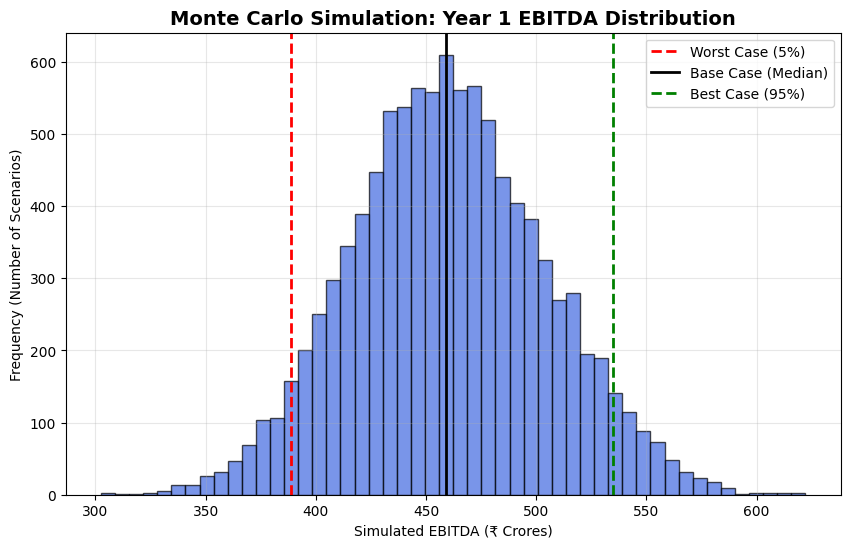

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the Static Base Assumptions (Year 0)
current_revenue = 1000 # Let's say ₹1,000 Crores
fixed_costs = 200      # ₹200 Crores (Rent, Salaries, etc. - doesn't change much)

# 2. Define the Probabilistic Variables (The Real World)
# Instead of a single number, we define a Mean (Expected) and Standard Deviation (Volatility)
simulations = 10000

# Revenue Growth: We expect 10% growth, but it could swing by 5% either way
rev_growth_mean = 0.10
rev_growth_std = 0.05

# COGS Margin: We expect materials to cost 40% of revenue, but inflation could swing it by 3%
cogs_margin_mean = 0.40
cogs_margin_std = 0.03

print(f"Running {simulations} Monte Carlo simulations for Year 1 Corporate Health...")

# 3. The Monte Carlo Engine
# Generate 10,000 random futures based on our assumed normal distributions
simulated_growth = np.random.normal(rev_growth_mean, rev_growth_std, simulations)
simulated_cogs_pct = np.random.normal(cogs_margin_mean, cogs_margin_std, simulations)

# Calculate the financials for all 10,000 parallel universes at once using vectorization
future_revenues = current_revenue * (1 + simulated_growth)
future_cogs = future_revenues * simulated_cogs_pct
gross_profits = future_revenues - future_cogs
ebitda_outcomes = gross_profits - fixed_costs

# 4. Analyze the Results (The FP&A Intelligence)
percentile_5 = np.percentile(ebitda_outcomes, 5)   # Worst Case (1-in-20 disaster)
median_ebitda = np.median(ebitda_outcomes)         # Base Case
percentile_95 = np.percentile(ebitda_outcomes, 95) # Best Case

print("\n" + "="*50)
print("📊 FP&A PROBABILISTIC FORECAST (YEAR 1 EBITDA)")
print("="*50)
print(f"🔴 Worst Case (5th Percentile):  ₹{percentile_5:.2f} Cr")
print(f"⚪ Base Case (Median):           ₹{median_ebitda:.2f} Cr")
print(f"🟢 Best Case (95th Percentile):  ₹{percentile_95:.2f} Cr")
print("-" * 50)

# Calculate the Probability of a specific disaster scenario
# Let's say the company breaches its bank debt covenants if EBITDA falls below ₹325 Cr
covenant_breach_threshold = 325
breaches = np.sum(ebitda_outcomes < covenant_breach_threshold)
breach_probability = (breaches / simulations) * 100

print(f"⚠️ Probability of breaching debt covenants (<₹{covenant_breach_threshold}Cr): {breach_probability:.1f}%")
print("="*50)

# 5. Visualization for the CFO Deck
plt.figure(figsize=(10, 6))
plt.hist(ebitda_outcomes, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(percentile_5, color='red', linestyle='dashed', linewidth=2, label='Worst Case (5%)')
plt.axvline(median_ebitda, color='black', linestyle='solid', linewidth=2, label='Base Case (Median)')
plt.axvline(percentile_95, color='green', linestyle='dashed', linewidth=2, label='Best Case (95%)')

plt.title('Monte Carlo Simulation: Year 1 EBITDA Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Simulated EBITDA (₹ Crores)')
plt.ylabel('Frequency (Number of Scenarios)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
import pandas as pd
import numpy as np

print("1. Ingesting Corporate Financial Data...")

# 1. Simulate the Static Budget Data (Usually from an Anaplan or Excel file)
budget_data = pd.DataFrame({
    'Department': ['Engineering', 'Marketing', 'Sales', 'HR', 'Legal', 'Product'],
    'Account_Type': ['Expense', 'Expense', 'Expense', 'Expense', 'Expense', 'Expense'],
    'Budget_Q1': [1500000, 800000, 1200000, 300000, 150000, 400000]
})

# 2. Simulate the Messy Actuals Data (Usually exported from SAP/Oracle ERP)
actuals_data = pd.DataFrame({
    'Dept_Name': ['Engineering', 'Marketing', 'Sales', 'HR', 'Legal', 'Product'],
    'Actual_Spend_Q1': [1550000, 950000, 1150000, 310000, 100000, 480000]
})

print("2. Running Automated BvA Reconciliation Engine...")

# 3. The Merge: Combining the datasets (replacing manual VLOOKUPs)
# We merge on the department name, assuming the ERP and Budget use slightly different column names
df_bva = pd.merge(budget_data, actuals_data, left_on='Department', right_on='Dept_Name')
df_bva.drop('Dept_Name', axis=1, inplace=True) # Clean up redundant column

# 4. FP&A Math: Calculating Variances
# For Expenses: Actual > Budget is BAD (Negative impact on bottom line).
# Standard FP&A convention is to show bad variances as negative or in parentheses.
df_bva['Variance_$'] = df_bva['Budget_Q1'] - df_bva['Actual_Spend_Q1']
df_bva['Variance_%'] = (df_bva['Variance_$'] / df_bva['Budget_Q1']) * 100

# 5. The "Auto-Commentary" Engine
# Instead of an analyst manually typing why a department missed the budget, the script flags it.
def generate_commentary(row):
    var_pct = row['Variance_%']
    var_dollars = row['Variance_$']

    # Materiality Threshold: We only care if the miss is greater than 5% AND $25,000
    if var_pct < -5 and abs(var_dollars) > 25000:
        return f"🚨 SEVERE OVERSPEND: Exceeded budget by {-var_pct:.1f}% (${abs(var_dollars):,.0f}). Immediate review required."
    elif var_pct > 5 and abs(var_dollars) > 25000:
        return f"🟢 SIGNIFICANT UNDERSPEND: Favorable variance of {var_pct:.1f}%. Assess if projects are delayed."
    else:
        return "In-Line with Budget."

df_bva['Executive_Commentary'] = df_bva.apply(generate_commentary, axis=1)

print("\n" + "="*80)
print("📊 Q1 EXECUTIVE BUDGET VS ACTUALS (BvA) REPORT")
print("="*80)

# 6. Format for the CFO's eyes
# We format the numbers to look like currency for readability
format_dict = {
    'Budget_Q1': '${0:,.0f}',
    'Actual_Spend_Q1': '${0:,.0f}',
    'Variance_$': '${0:,.0f}',
    'Variance_%': '{0:.1f}%'
}

# Print the final clean dataframe
print(df_bva[['Department', 'Budget_Q1', 'Actual_Spend_Q1', 'Variance_$', 'Variance_%', 'Executive_Commentary']].style.format(format_dict).to_string())

print("-" * 80)
# Calculate the total corporate burn rate
total_budget = df_bva['Budget_Q1'].sum()
total_actual = df_bva['Actual_Spend_Q1'].sum()
total_variance = total_budget - total_actual
total_var_pct = (total_variance / total_budget) * 100

print(f"🏢 TOTAL CORPORATE OPEX: Budgeted ${total_budget:,.0f} | Actual ${total_actual:,.0f}")
print(f"📈 NET RUN RATE: ${total_variance:,.0f} ({total_var_pct:.1f}%)")
print("="*80)

1. Ingesting Corporate Financial Data...
2. Running Automated BvA Reconciliation Engine...

📊 Q1 EXECUTIVE BUDGET VS ACTUALS (BvA) REPORT
 Department Budget_Q1 Actual_Spend_Q1 Variance_$ Variance_% Executive_Commentary
0 Engineering $1,500,000 $1,550,000 $-50,000 -3.3% In-Line with Budget.
1 Marketing $800,000 $950,000 $-150,000 -18.8% 🚨 SEVERE OVERSPEND: Exceeded budget by 18.8% ($150,000). Immediate review required.
2 Sales $1,200,000 $1,150,000 $50,000 4.2% In-Line with Budget.
3 HR $300,000 $310,000 $-10,000 -3.3% In-Line with Budget.
4 Legal $150,000 $100,000 $50,000 33.3% 🟢 SIGNIFICANT UNDERSPEND: Favorable variance of 33.3%. Assess if projects are delayed.
5 Product $400,000 $480,000 $-80,000 -20.0% 🚨 SEVERE OVERSPEND: Exceeded budget by 20.0% ($80,000). Immediate review required.

--------------------------------------------------------------------------------
🏢 TOTAL CORPORATE OPEX: Budgeted $4,350,000 | Actual $4,540,000
📈 NET RUN RATE: $-190,000 (-4.4%)
